In [86]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.utilities import ricker_wavelet, green2d

In [88]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX
    "font.family": "serif",      # Use serif fonts
    "font.size": 18,             # Set font size
    "axes.labelsize": 18,        # Label font size
    "legend.fontsize": 18,       # Legend font size
    "xtick.labelsize": 18,       # X-axis tick size
    "ytick.labelsize": 18,       # Y-axis tick size
    "figure.figsize": (8,6),     # Set figure size
    "lines.linewidth": 1.5,        # Line thickness
    "grid.alpha": 0.5,           # Grid transparency
    "savefig.dpi": 300           # High-resolution images
})

In [89]:
'''layers = [
        (300.0, 2300.0, 2000.0), # top layer
        (350.0, 2000.0, 2000.0),
    ]'''

'layers = [\n        (300.0, 2300.0, 2000.0), # top layer\n        (350.0, 2000.0, 2000.0),\n    ]'

In [90]:
layers = [
        (100.0, 1505.0, 2000.0), # top layer
        (200.0, 1603.0, 2000.0),
        (250.0, 1749.0, 2000.0),
        (350.0, 2019.0, 2000.0),
        (450.0, 2179.0, 2000.0),
        (550.0, 1900.0, 2000.0),
        (650.0, 2265.0, 2000.0),
        (700.0, 3281.0, 2000.0),
    ]

In [91]:
param = Parameters(total_time=1.024, nt=1024, freq=15., nfft=2048)

# x and z positions of sources
sources = [(30.0, 76.0), (150.0, 76.0)]#], (250.0, 76.0), (350.0, 76.0), (480.0, 76.0), (620.0, 76.0)]
# x and z positions of receivers
Nr = 128 # 128
x_receivers = np.linspace(0.0, 1000.0, Nr)
receivers = [(x, 76.0) for x in x_receivers]
print(receivers)
acq = Acquisition(sources, receivers)

[(np.float64(0.0), 76.0), (np.float64(7.874015748031496), 76.0), (np.float64(15.748031496062993), 76.0), (np.float64(23.62204724409449), 76.0), (np.float64(31.496062992125985), 76.0), (np.float64(39.37007874015748), 76.0), (np.float64(47.24409448818898), 76.0), (np.float64(55.118110236220474), 76.0), (np.float64(62.99212598425197), 76.0), (np.float64(70.86614173228347), 76.0), (np.float64(78.74015748031496), 76.0), (np.float64(86.61417322834646), 76.0), (np.float64(94.48818897637796), 76.0), (np.float64(102.36220472440945), 76.0), (np.float64(110.23622047244095), 76.0), (np.float64(118.11023622047244), 76.0), (np.float64(125.98425196850394), 76.0), (np.float64(133.85826771653544), 76.0), (np.float64(141.73228346456693), 76.0), (np.float64(149.60629921259843), 76.0), (np.float64(157.48031496062993), 76.0), (np.float64(165.35433070866142), 76.0), (np.float64(173.22834645669292), 76.0), (np.float64(181.10236220472441), 76.0), (np.float64(188.9763779527559), 76.0), (np.float64(196.85039370

In [92]:
d_cal = forward(layers, acq, param, free_surface=False, nq_prop=512, nq_evan=64)

max epsilon = 3.820334966238424
kx quadrature elapsed: 58.63 s


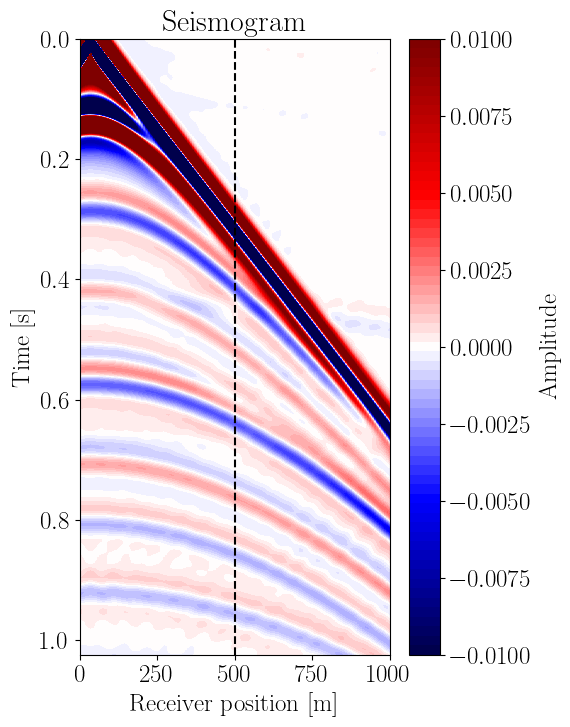

In [98]:
d_cal_seis = d_cal[0, :, :]

Ncolors = 65
cmap = plt.cm.seismic
colors = cmap(np.linspace(0, 1, Ncolors))
cmap_discrete = ListedColormap(colors)
plt.figure(figsize=(5,8))
plt.imshow(d_cal_seis.T, aspect='auto', origin='upper', 
           extent=[np.min(acq.xr), np.max(acq.xr), param.time[-1], param.time[0]],
           cmap=cmap_discrete, vmin=-0.01, vmax=0.01)
plt.colorbar(label='Amplitude')
plt.axvline(x=500, linewidth=1.5, linestyle='--', color='black')
plt.xlabel('Receiver position [m]')
plt.ylabel('Time [s]')
plt.title('Seismogram ')
plt.show()

Delay 0.2
Reflection coeff: 0.03153153153153153
time refl -0.01760797342192691 seconds
time refl 2 fs 0.03289036544850499 seconds
time refl 0.11528239202657806 seconds
r_dist 442.4409448818898 r_travel 445.0370655439605


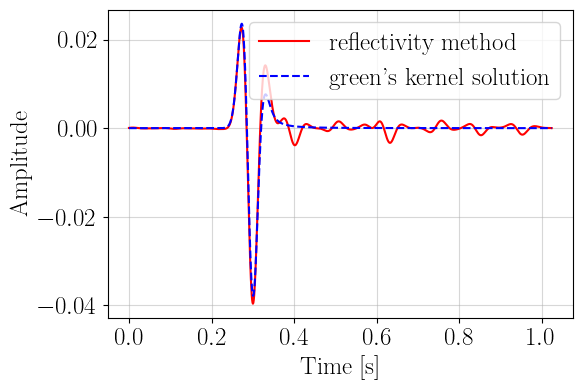

In [94]:
# validation with green's function in frequency domain
rn = 60
sn = 0
freqs = np.fft.rfftfreq(param.nfft, param.dt)
omegas = 2.0 * np.pi * freqs  + 1j * 1e-12
s_t, delay = ricker_wavelet(param.time, param.freq)
print("Delay", delay)
s_w = np.conj(np.fft.rfft(np.conj(s_t), n=param.nfft)) 

Reflection = (layers[1][1] - layers[0][1])/(layers[0][1] + layers[1][1])
print("Reflection coeff:", Reflection)
vp = layers[0][1]
h = layers[0][0]
r_dist = np.sqrt( (acq.xs[sn] - acq.xr[rn])**2 + (acq.zs[sn] - acq.zr[rn])**2 )
r_travel = 2.*np.sqrt( (h-acq.zs[sn])**2 + (0.5*(acq.xs[sn] - acq.xr[rn]))**2 )
time_reflection = (2*h - 76.) / (vp) - 0.1
print("time refl", time_reflection, "seconds")

time_reflection2 = (2*h - 0.) / (vp) - 0.1
print("time refl 2 fs", time_reflection2, "seconds")

time_reflection3 = (4*h - 76.) / (vp) - 0.1
print("time refl", time_reflection3, "seconds")

print("r_dist", r_dist, "r_travel", r_travel)
T_ref = s_w*(green2d(omegas, vp, r_dist) + Reflection*green2d(omegas, vp, r_travel)) * np.exp(-1j * delay * omegas)
# T_ref *= 1j*omegas # ricker source time-derivative !
S_ref = np.conj(np.fft.irfft(np.conj(T_ref), n=param.nfft))
S_ref = S_ref[:param.nt]

plt.figure(figsize=(6,4))
plt.plot(param.time, d_cal[sn, rn, :], 'r-', label='reflectivity method')
plt.plot(param.time, S_ref, 'b--', label='green\'s kernel solution')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
#plt.ylim(-0.05, 0.05)

In [95]:
from src.misfit import l2_misfit
misfit = l2_misfit(d_cal[sn, rn, :], S_ref, layers=layers, acqui=acq, param=param)
print("L2 misfit between reflectivity and green's function solution:", misfit)

L2 misfit between reflectivity and green's function solution: 0.0008638017882522547
